In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import lightgbm as lgb
from prophet import Prophet
import shap

from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

shap.initjs()

In [2]:
df = pd.read_csv("meta_dataset.csv")

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df.head()

,date,day_of_week,is_weekend,user_id,signup_days_ago,age_group,gender,location,device_type,session_count,...,internet_speed_category,device_performance_score,time_of_day_activity,holiday_flag,engagement_score,scroll_depth,interaction_diversity,content_consumption_rate,habit_score,churn_flag
3909,2018-01-01 00:10:00,0,0,11821,1736,25-34,M,Germany,mobile,3,...,low,0.591387,afternoon,1,86.221429,0.050335,0.858699,0.085565,128.240860,1
21485,2018-01-01 02:01:00,0,0,27105,160,35-44,F,India,mobile,2,...,high,0.589877,night,0,113.611194,0.422826,0.207066,0.755908,156.683415,0
47378,2018-01-01 02:29:00,0,0,5126,2478,18-24,Other,UK,tablet,5,...,high,0.957770,afternoon,1,139.979374,0.969517,0.996122,0.033631,77.459219,1
74704,2018-01-01 05:19:00,0,0,17149,1728,35-44,Other,UK,tablet,0,...,high,0.084625,morning,1,143.517393,0.428317,0.689923,0.893166,184.892124,1
7658,2018-01-01 06:17:00,0,0,16725,1678,45+,Other,Germany,mobile,1,...,high,0.126482,night,0,142.680388,0.729221,0.194357,0.455674,77.046264,1


In [3]:
daily = df.groupby(df['date'].dt.date).agg({
    'user_id': 'nunique',
    'session_count': 'mean',
    'watch_time': 'mean',
    'engagement_score': 'mean',
    'ads_seen': 'mean',
    'revenue_per_user': 'mean'
}).reset_index()

daily.columns = ['ds','y','session_count','watch_time','engagement','ads','revenue']
daily['ds'] = pd.to_datetime(daily['ds'])

In [4]:
# LAGS
for lag in [1, 2, 3, 5, 7, 14, 21, 30]:
    daily[f'lag_{lag}'] = daily['y'].shift(lag)

# ROLLING
daily['rolling_mean_7'] = daily['y'].rolling(7).mean()
daily['rolling_mean_14'] = daily['y'].rolling(14).mean()
daily['rolling_std_7'] = daily['y'].rolling(7).std()

# EXTREME VALUES
daily['rolling_max_7'] = daily['y'].rolling(7).max()
daily['rolling_min_7'] = daily['y'].rolling(7).min()

# MOMENTUM
daily['momentum_3'] = daily['y'] - daily['y'].shift(3)
daily['momentum_7'] = daily['y'] - daily['y'].shift(7)

# TREND
daily['trend_strength'] = daily['rolling_mean_7'] - daily['rolling_mean_14']

# GROWTH
daily['growth_rate'] = daily['y'].pct_change()

# BEHAVIOR SIGNALS
daily['engagement_per_user'] = daily['engagement'] / (daily['y'] + 1e-5)
daily['ads_per_user'] = daily['ads'] / (daily['y'] + 1e-5)

daily['engagement_x_trend'] = daily['engagement'] * daily['trend_strength']
daily['ads_x_engagement'] = daily['ads'] * daily['engagement']

# CHANGE FEATURES
daily['engagement_change'] = daily['engagement'].diff()
daily['ads_change'] = daily['ads'].diff()

# DATE FEATURES
daily['day_of_week'] = daily['ds'].dt.dayofweek
daily['is_weekend'] = daily['day_of_week'].isin([5,6]).astype(int)

daily = daily.dropna()

In [5]:
prophet_temp = Prophet(
    weekly_seasonality=True,
    yearly_seasonality=True,
    daily_seasonality=False
)

prophet_temp.fit(daily[['ds','y']])

forecast = prophet_temp.predict(daily[['ds']])

daily['prophet_trend'] = forecast['trend']
daily['prophet_seasonal'] = forecast['weekly'] + forecast['yearly']

13:44:36 - cmdstanpy - INFO - Chain [1] start processing
13:44:37 - cmdstanpy - INFO - Chain [1] done processing


In [6]:
daily_mh = daily.copy()

daily_mh['y_t+1'] = daily_mh['y'].shift(-1)
daily_mh['y_t+7'] = daily_mh['y'].shift(-7)
daily_mh['y_t+30'] = daily_mh['y'].shift(-30)

daily_mh = daily_mh.dropna()

In [7]:
split = int(len(daily_mh) * 0.8)

train = daily_mh.iloc[:split]
test = daily_mh.iloc[split:]

In [8]:
features = [col for col in train.columns if col not in [
    'ds','y','y_t+1','y_t+7','y_t+30'
]]

X_train = train[features]
X_test = test[features]

y_train_1 = train['y_t+1']
y_train_7 = train['y_t+7']
y_train_30 = train['y_t+30']

y_test_1 = test['y_t+1']
y_test_7 = test['y_t+7']
y_test_30 = test['y_t+30']

In [9]:
scaler = StandardScaler()

X_train = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns
)

In [10]:
param_grid = {
    'n_estimators': [1000, 2000, 3000],
    'learning_rate': [0.01, 0.015, 0.02],
    'num_leaves': [64, 128, 256],
    'min_data_in_leaf': [3, 5],
    'subsample': [0.8, 0.9],
    'colsample_bytree': [0.8, 0.9]
}

search = RandomizedSearchCV(
    lgb.LGBMRegressor(verbosity=-1, random_state=42),
    param_grid,
    n_iter=10,
    scoring='neg_mean_absolute_error',
    cv=3,
    n_jobs=-1
)

search.fit(X_train, y_train_1)

best_params = search.best_params_
print(best_params)

{'subsample': 0.9, 'num_leaves': 128, 'n_estimators': 3000, 'min_data_in_leaf': 5, 'learning_rate': 0.02, 'colsample_bytree': 0.8}


In [11]:
def train_model(y):
    model = lgb.LGBMRegressor(
        n_estimators=4000,
        learning_rate=0.01,
        num_leaves=256,
        max_depth=-1,
        min_data_in_leaf=2,
        subsample=0.9,
        colsample_bytree=0.9,
        reg_alpha=0.1,
        reg_lambda=0.1,
        verbosity=-1,
        random_state=42
    )
    
    model.fit(X_train, y)
    return model

model_1 = train_model(y_train_1)
model_7 = train_model(y_train_7)
model_30 = train_model(y_train_30)

In [12]:
pred_1 = model_1.predict(X_test)
pred_7 = model_7.predict(X_test)
pred_30 = model_30.predict(X_test)

In [13]:
def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred)/(y_true+1e-5))) * 100
    
    print(f"{name}: MAE={mae:.3f}, RMSE={rmse:.3f}, MAPE={mape:.2f}%")

evaluate(y_test_1, pred_1, "t+1")
evaluate(y_test_7, pred_7, "t+7")
evaluate(y_test_30, pred_30, "t+30")

t+1: MAE=4.716, RMSE=5.906, MAPE=15.86%
t+7: MAE=4.624, RMSE=5.778, MAPE=15.58%
t+30: MAE=4.551, RMSE=5.713, MAPE=15.38%


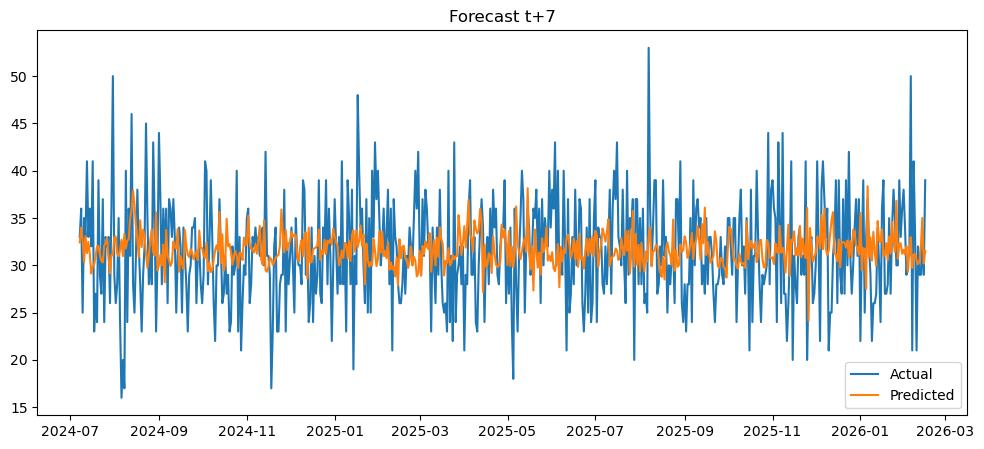

In [14]:
plt.figure(figsize=(12,5))
plt.plot(test['ds'], y_test_7, label='Actual')
plt.plot(test['ds'], pred_7, label='Predicted')
plt.legend()
plt.title("Forecast t+7")
plt.show()

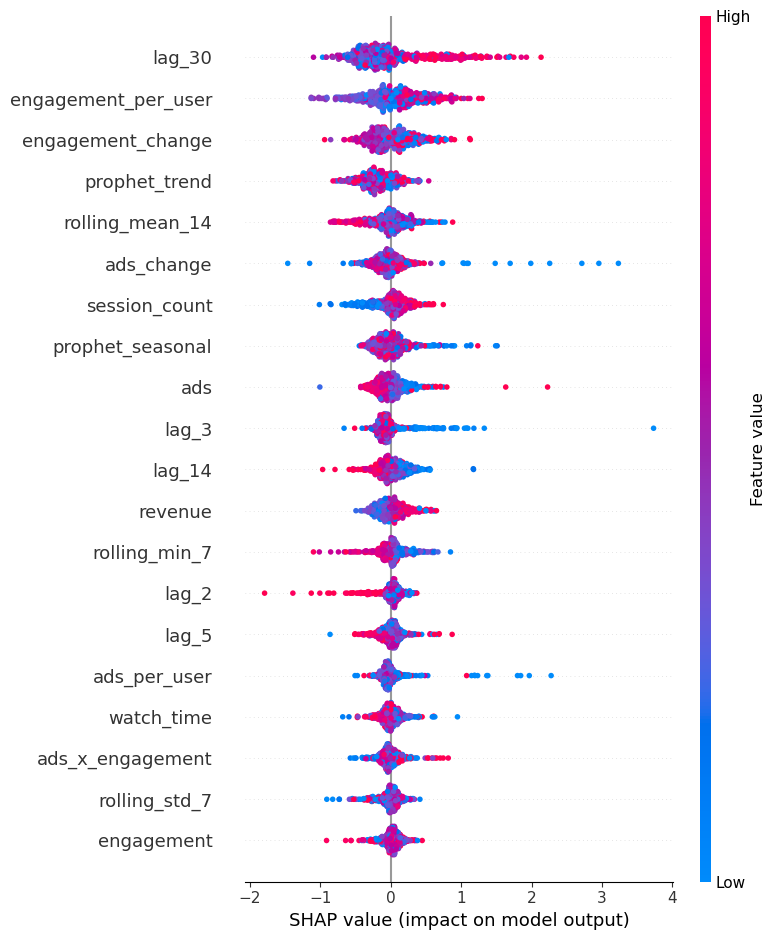

In [15]:
explainer = shap.TreeExplainer(model_7)

shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test)

In [16]:
# Explain a single prediction
index = 0

shap.force_plot(
    explainer.expected_value,
    shap_values[index],
    X_test.iloc[index]
)

In [17]:
last_row = daily_mh.iloc[-1]

X_future = pd.DataFrame([last_row[features]])

future_pred = {
    "Next Day": model_1.predict(X_future)[0],
    "Next 7 Days": model_7.predict(X_future)[0],
    "Next 30 Days": model_30.predict(X_future)[0]
}

future_pred

{'Next Day': np.float64(34.40899532724904),
 'Next 7 Days': np.float64(32.413317944102786),
 'Next 30 Days': np.float64(32.58265518682095)}

In [18]:
def accuracy_score(y_true, y_pred, name):
    mape = np.mean(np.abs((y_true - y_pred) / (y_true + 1e-5)))
    acc = 1 - mape
    
    print(f"{name} Accuracy: {acc:.3f}")
    return acc

acc_1 = accuracy_score(y_test_1, pred_1, "t+1")
acc_7 = accuracy_score(y_test_7, pred_7, "t+7")
acc_30 = accuracy_score(y_test_30, pred_30, "t+30")

t+1 Accuracy: 0.841
t+7 Accuracy: 0.844
t+30 Accuracy: 0.846


In [19]:
print("Total Features:", len(features))
print(features)

Total Features: 32
['session_count', 'watch_time', 'engagement', 'ads', 'revenue', 'lag_1', 'lag_2', 'lag_3', 'lag_5', 'lag_7', 'lag_14', 'lag_21', 'lag_30', 'rolling_mean_7', 'rolling_mean_14', 'rolling_std_7', 'rolling_max_7', 'rolling_min_7', 'momentum_3', 'momentum_7', 'trend_strength', 'growth_rate', 'engagement_per_user', 'ads_per_user', 'engagement_x_trend', 'ads_x_engagement', 'engagement_change', 'ads_change', 'day_of_week', 'is_weekend', 'prophet_trend', 'prophet_seasonal']


In [20]:

future_dates = []
future_preds = []

last_row = daily.iloc[-1].copy()

for i in range(30):
    
    next_date = last_row['ds'] + pd.Timedelta(days=1)
    
    row = last_row.copy()
    row['ds'] = next_date

    for lag in [1,2,3,5,7,14,21,30]:
        row[f'lag_{lag}'] = daily['y'].iloc[-lag]

    # Rolling features
    row['rolling_mean_7'] = daily['y'].iloc[-7:].mean()
    row['rolling_mean_14'] = daily['y'].iloc[-14:].mean()
    row['rolling_std_7'] = daily['y'].iloc[-7:].std()
    row['rolling_max_7'] = daily['y'].iloc[-7:].max()
    row['rolling_min_7'] = daily['y'].iloc[-7:].min()

    # Momentum
    row['momentum_3'] = daily['y'].iloc[-1] - daily['y'].iloc[-3]
    row['momentum_7'] = daily['y'].iloc[-1] - daily['y'].iloc[-7]

    # Trend
    row['trend_strength'] = row['rolling_mean_7'] - row['rolling_mean_14']

    # Growth
    row['growth_rate'] = (daily['y'].iloc[-1] - daily['y'].iloc[-2]) / (daily['y'].iloc[-2] + 1e-5)

    # Date features
    row['day_of_week'] = next_date.dayofweek
    row['is_weekend'] = 1 if next_date.dayofweek in [5,6] else 0

    # Prophet trend (IMPORTANT)
    prophet_val = prophet_temp.predict(pd.DataFrame({'ds':[next_date]}))
    row['prophet_trend'] = prophet_val['trend'].values[0]
    row['prophet_seasonal'] = prophet_val['weekly'].values[0]

    X_fut = pd.DataFrame([row[features]])
    
    if i == 0:
        pred = model_1.predict(X_fut)[0]
    elif i < 7:
        pred = model_7.predict(X_fut)[0]
    else:
        pred = model_30.predict(X_fut)[0]

    # Prevent unrealistic jumps
    pred = np.clip(pred, 15, 60)

    # Save
    future_dates.append(next_date)
    future_preds.append(pred)

    # Update state
    last_row['y'] = pred
    last_row['ds'] = next_date
    new_row = pd.DataFrame([last_row])

    # Ensure same columns
    new_row = new_row.reindex(columns=daily.columns)

    daily = pd.concat([daily, new_row], ignore_index=True)

# Final dataframe
future_df = pd.DataFrame({
    'date': future_dates,
    'predicted_DAU': future_preds
})

future_df

,date,predicted_DAU
0,2026-03-18,31.530099
1,2026-03-19,30.810393
2,2026-03-20,31.162397
3,2026-03-21,30.984379
4,2026-03-22,31.510859
5,2026-03-23,31.568432
6,2026-03-24,31.372756
7,2026-03-25,27.908203
8,2026-03-26,33.911031
9,2026-03-27,28.889297


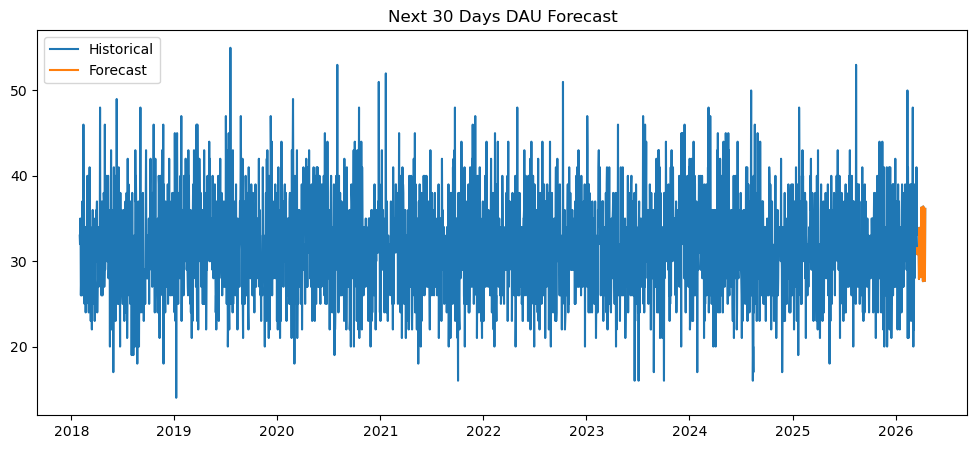

In [21]:
plt.figure(figsize=(12,5))

plt.plot(daily['ds'], daily['y'], label='Historical')
plt.plot(future_df['date'], future_df['predicted_DAU'], label='Forecast')

plt.legend()
plt.title("Next 30 Days DAU Forecast")
plt.show()